# EU Environmental Protection Investment Analysis

In [74]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import numpy as np
import pandas as pd
import requests
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import textwrap
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


## Global Settings

In [76]:
# Get current date in YYYYMMDD format
current_date = datetime.now().strftime("%Y%m%d")

# Define the base directory for outputs
FIGURES_PATH = os.path.join("..", "figures")
MODELS_PATH = os.path.join("..", "models")
RESULTS_PATH = os.path.join("..", "results")
DATA_PATH = os.path.join("..", "data")

# Ensure the directory exists
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)
os.makedirs(DATA_PATH, exist_ok=True)

print(f"Global paths set:\n \
      - Figures: {os.path.abspath(FIGURES_PATH)}\n \
      - Models: {os.path.abspath(MODELS_PATH)}\n \
      - Results: {os.path.abspath(RESULTS_PATH)}\n \
      - Data: {os.path.abspath(DATA_PATH)}")

Global paths set:
       - Figures: /home/daniel/projects/SS2026_TU_Wien/Data_Stewardship/Environmental_Protection_Investment_Analysis/figures
       - Models: /home/daniel/projects/SS2026_TU_Wien/Data_Stewardship/Environmental_Protection_Investment_Analysis/models
       - Results: /home/daniel/projects/SS2026_TU_Wien/Data_Stewardship/Environmental_Protection_Investment_Analysis/results
       - Data: /home/daniel/projects/SS2026_TU_Wien/Data_Stewardship/Environmental_Protection_Investment_Analysis/data


## Data Preprocessing

In [ ]:
# ============================================================
# DBRepo REST API configuration (T2.6 reimplementation)
# ============================================================
# All input data is loaded from DBRepo via REST. No local file
# reads. See README "Data loading from DBRepo" section.

DBREPO_BASE_URL    = "https://test.dbrepo.tuwien.ac.at/api/v1"
DBREPO_DATABASE_ID = "123289f2-5218-4b32-b962-5f3dafec1fe3"

# Resolved against the live DBRepo deployment. Refresh by
# running GET /api/v1/database/{id} if the database is rebuilt.
DBREPO_TABLE_IDS = {
    "Country":                 "e0b8218b-0b56-4229-a251-7c740ae4404f",
    "Environmental_Activity":  "3fc4c422-c1ae-42d4-a158-4e2a4a2ad37a",
    "Macroeconomic_Indicator": "ca99f3b3-dd67-4df7-9505-5ec0f7a922a6",
    "Environmental_Investment":"4f9588d7-45f1-432e-91b9-c9ae5d0fb22c",
}

# The three views from database/views.sql are also registered in
# DBRepo, but DBRepo's UI does not support computed columns or
# multi-column join conditions, so the live view definitions
# differ from views.sql: v_investment_national_totals has a
# cartesian explosion on the macroeconomic join (missing year
# condition), and v_ml_regression_features has none of the log_*
# columns. We therefore fetch the four base tables and reproduce
# the view logic in pandas below.

PAGE_SIZE = 10000

def fetch_dbrepo_table(table_id, *, base=DBREPO_BASE_URL,
                       db=DBREPO_DATABASE_ID, page_size=PAGE_SIZE):
    """Fetch all rows from a DBRepo base table via the REST API.

    Pages through results, raises on connection or HTTP errors,
    and returns a pandas DataFrame. NULL columns are materialised
    as NaN.
    """
    url = f"{base}/database/{db}/table/{table_id}/data"
    rows, page = [], 0
    while True:
        try:
            r = requests.get(
                url,
                headers={"Accept": "application/json"},
                params={"page": page, "size": page_size},
                timeout=30,
            )
        except requests.exceptions.ConnectionError as e:
            raise RuntimeError(f"DBRepo unreachable at {url}: {e}") from e
        if r.status_code != 200:
            raise RuntimeError(
                f"DBRepo returned HTTP {r.status_code} for {url}: "
                f"{r.text[:200]}"
            )
        try:
            chunk = r.json()
        except ValueError as e:
            raise RuntimeError(f"DBRepo response was not JSON: {e}") from e
        if not isinstance(chunk, list):
            raise RuntimeError(
                f"Unexpected DBRepo payload shape: {type(chunk).__name__}"
            )
        rows.extend(chunk)
        if len(chunk) < page_size:
            break
        page += 1
    return pd.DataFrame(rows)


In [78]:
def plot_missing_data_heatmap(df_long, value_col, title, filename):
    """
    Creates a heatmap showing the count of missing values per country and year.
    """
    # Create helper for missing values
    df_temp = df_long.copy()
    df_temp['is_missing'] = df_temp[value_col].isnull().astype(int)
    
    # Pivot for the heatmap
    missing_counts = df_temp.pivot_table(
        index='country_name', 
        columns='year', 
        values='is_missing', 
        aggfunc='sum'
    )
    
    # Plotting
    plt.figure(figsize=(16, 10))
    sns.heatmap(missing_counts, annot=True, fmt='g', cmap='YlOrRd', 
                linewidths=.5, linecolor='lightgray',
                cbar_kws={'label': 'Number of Missing Values'})
    
    # 4. Save figure using the global path
    # save_path = os.path.join(FIGURES_PATH, filename)
    # plt.savefig(save_path, bbox_inches='tight', dpi=300)
    
    # print(f"Plot saved successfully to: {save_path}")

    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel('Country')
    plt.show()

### Environmental Protection Data

In [ ]:
# Fetch the four base tables from DBRepo via REST.
df_country  = fetch_dbrepo_table(DBREPO_TABLE_IDS["Country"])
df_activity = fetch_dbrepo_table(DBREPO_TABLE_IDS["Environmental_Activity"])
df_macro    = fetch_dbrepo_table(DBREPO_TABLE_IDS["Macroeconomic_Indicator"])
df_inv      = fetch_dbrepo_table(DBREPO_TABLE_IDS["Environmental_Investment"])

print(f"Country:                  {len(df_country):>5} rows")
print(f"Environmental_Activity:   {len(df_activity):>5} rows")
print(f"Macroeconomic_Indicator:  {len(df_macro):>5} rows")
print(f"Environmental_Investment: {len(df_inv):>5} rows")

# Reproduce the schema the downstream pipeline expects:
# columns geo, country_name, year, ceparema, activity, inv_*.
df_investments = (
    df_inv
    .merge(df_country,  on="country_code", how="left")
    .merge(df_activity, on="ceparema_code", how="left")
    .rename(columns={
        "country_code":  "geo",
        "ceparema_code": "ceparema",
        "activity_name": "activity",
    })
)

# Match the original notebook's df_gov-as-base merge semantics:
# the source dataset env_ac_epigg1 (general government investments)
# does not publish values for several non-EU countries (e.g. Serbia,
# North Macedonia), so the original pipeline implicitly excluded them
# at the merge boundary. We reproduce that by dropping countries that
# never report any inv_gov value across the full table.
_countries_with_gov = df_investments.loc[df_investments['inv_gov'].notna(), 'geo'].unique()
df_investments = df_investments[df_investments['geo'].isin(_countries_with_gov)].copy()

# Per-sector convenience frames used by the missing-data heatmaps.
df_gov       = df_investments[["geo", "country_name", "year", "ceparema", "activity", "inv_gov"]].copy()
df_corp_spec = df_investments[["geo", "country_name", "year", "ceparema", "activity", "inv_corp_spec"]].copy()
df_corp_anc  = df_investments[["geo", "country_name", "year", "ceparema", "activity", "inv_corp_anc"]].copy()

plot_missing_data_heatmap(df_gov,       "inv_gov",       "Missing Values: Investments of general government",                                  "missing_data_heatmap_gov_investment.png")
plot_missing_data_heatmap(df_corp_spec, "inv_corp_spec", "Missing Values: investments of corporations as specialist and secondary producers",  "missing_data_heatmap_corp_spec_investment.png")
plot_missing_data_heatmap(df_corp_anc,  "inv_corp_anc",  "Missing Values: Ancillary Investment",                                                "missing_data_heatmap_corp_anc_investment.png")


Data availability for ancillary producers (integrated technologies) is more fragmented than for government expenditures. Some nations are omitted from the analysis due to non-reporting or lack of data within the specific Eurostat classifications (EP_BSN).

In [ ]:
# Define valid years for analysis
valid_years = range(2014, 2023)  # 2014-2022 inclusive

# Filter all dataframes to the analysis window
df_investments = df_investments[df_investments['year'].isin(valid_years)].copy()
df_gov         = df_gov[df_gov['year'].isin(valid_years)].copy()
df_corp_spec   = df_corp_spec[df_corp_spec['year'].isin(valid_years)].copy()
df_corp_anc    = df_corp_anc[df_corp_anc['year'].isin(valid_years)].copy()


In [82]:
df_corp_spec.head()

,ceparema,unit,geo,country_name,activity,year,inv_corp_spec
2592,CEPA1,MIO_EUR,AT,Austria,Protection of ambient air and climate,2014,5.8
2593,CEPA1,MIO_EUR,BA,Bosnia and Herzegovina,Protection of ambient air and climate,2014,NaN
2594,CEPA1,MIO_EUR,BE,Belgium,Protection of ambient air and climate,2014,10.2
2595,CEPA1,MIO_EUR,BG,Bulgaria,Protection of ambient air and climate,2014,0.0
2596,CEPA1,MIO_EUR,CH,Switzerland,Protection of ambient air and climate,2014,5.8


In [83]:
df_gov.head()

,ceparema,unit,geo,country_name,activity,year,inv_gov
2544,CEPA1,MIO_EUR,AT,Austria,Protection of ambient air and climate,2014,6.2
2545,CEPA1,MIO_EUR,BE,Belgium,Protection of ambient air and climate,2014,3.5
2546,CEPA1,MIO_EUR,BG,Bulgaria,Protection of ambient air and climate,2014,1.7
2547,CEPA1,MIO_EUR,CH,Switzerland,Protection of ambient air and climate,2014,1.6
2548,CEPA1,MIO_EUR,CY,Cyprus,Protection of ambient air and climate,2014,NaN


In [84]:
df_corp_anc.head()

,geo,year,ceparema,country_name,activity,inv_corp_anc
88,AT,2014,CEPA1,Austria,Protection of ambient air and climate,103.5
89,AT,2014,CEPA2,Austria,Wastewater management,24.4
90,AT,2014,CEPA3,Austria,Waste management,26.8
91,AT,2014,CEPA4,Austria,"Protection and remediation of soil, groundwate...",28.2
92,AT,2014,CEPA5,Austria,Noise and vibration abatement (excluding workp...,20.0


### Wealth & Population Data

In [ ]:
# Real GDP per capita: projected from the Macroeconomic_Indicator
# table fetched above. Filtered to the analysis window 2014-2022.
df_gdp = (
    df_macro[["country_code", "year", "gdp_per_capita"]]
    .rename(columns={"country_code": "geo"})
)
df_gdp = df_gdp[df_gdp["year"].between(2014, 2022)].reset_index(drop=True)
df_gdp.head()


In [ ]:
# Population on 1 January: projected from the same
# Macroeconomic_Indicator table. Filtered to 2014-2022.
df_pop = (
    df_macro[["country_code", "year", "population"]]
    .rename(columns={"country_code": "geo"})
)
df_pop = df_pop[df_pop["year"].between(2014, 2022)].reset_index(drop=True)
df_pop.head()


### Merging and Enrichment of Environmental Investment Data

Merge Investment Data

In [91]:
df_investments.describe()

,year,inv_gov,inv_corp_spec,inv_corp_anc
count,2862.00000,2621.0,2383.0,1339.0
mean,2018.00000,181203624.570775,150010365.086026,93031217.326363
std,2.58244,619400859.885838,602251751.949526,302465014.042645
min,2014.00000,-33400000.0,0.0,0.0
25%,2016.00000,200000.0,0.0,200000.0
50%,2018.00000,9200000.0,1800000.0,7600000.0
75%,2020.00000,69100000.0,48750000.0,49900000.0
max,2022.00000,8694500000.0,8209500000.0,3822200000.0


Negative investment figures were observed in the government sector, specifically for Estonia in 2021 and 2022. In national accounting, these anomalies could represent 'net disposals,' where the sale of existing environmental assets exceeds new acquisitions or they may result from the repayment of investment grants and internal reclassifications. To ensure model stability and compatibility with log-transformations, these values were clipped to zero

In [93]:
# Identify numeric columns (inv_gov, inv_corp_spec, inv_corp_anc)
num_cols = df_investments.select_dtypes(include='number').columns

# Correct negative values to 0 before calculating any totals
df_investments[num_cols] = df_investments[num_cols].clip(lower=0)
print(f"Applied clipping to: {', '.join(num_cols)}")

Applied clipping to: year, inv_gov, inv_corp_spec, inv_corp_anc


In [94]:
# Calculate total corporate and overall investment before splitting
df_investments['inv_corp_total'] = df_investments['inv_corp_spec'].fillna(0) + df_investments['inv_corp_anc'].fillna(0)
df_investments['inv_total'] = df_investments['inv_gov'].fillna(0) + df_investments['inv_corp_total']

Split datasets

In [95]:
# VIEW A: Sector Breakdown (For Trend Analysis)
df_cepa_breakdown = df_investments[df_investments['ceparema'] != 'TOT_CEPA'].copy()

# VIEW B: National Totals (For Regression & Clustering)
df_cepa_totals = df_investments[df_investments['ceparema'] == 'TOT_CEPA'].copy()

Enrichment of aggregate values (View B)

In [96]:
# Add GDP and Population to Totals only
for extra_df, extra_cols in [
    (df_gdp, ['geo', 'year', 'gdp_per_capita']),
    (df_pop, ['geo', 'year', 'population'])
]:
    df_cepa_totals = df_cepa_totals.merge(
        extra_df[extra_cols],
        on=['geo', 'year'],
        how='left'
    )

# Calculate Per Capita Investment
df_cepa_totals['inv_per_capita'] = df_cepa_totals['inv_total'] / df_cepa_totals['population']

In [97]:
# Record row count before merging GDP and Population
rows_before_extra = len(df_cepa_totals)

# Check for row inflation before dropping NaNs
if len(df_cepa_totals) != rows_before_extra:
    print(f"Warning: Row count changed from {rows_before_extra} to {len(df_cepa_totals)} during enrichment.")
else:
    print("Validation successful: No row inflation during GDP/Population merge.")

Validation successful: No row inflation during GDP/Population merge.


Sort columns

In [98]:
# Define column orders
cols_base = ['year', 'geo', 'country_name', 'ceparema', 'activity', 
             'inv_gov', 'inv_corp_spec', 'inv_corp_anc', 'inv_corp_total', 'inv_total']

cols_totals = cols_base + ['population', 'inv_per_capita', 'gdp_per_capita']

# Apply ordering
df_cepa_breakdown = df_cepa_breakdown[cols_base]
df_cepa_totals = df_cepa_totals[cols_totals]

# Final Check
print(f"Check: {df_cepa_totals['country_name'].nunique()} countries in Totals view.")
print(f"Check: {df_cepa_totals['ceparema'].nunique()} protection sector in Totals view.")

print(f"Check: {df_cepa_breakdown['country_name'].nunique()} countries in Breakdown view.")
print(f"Check: {df_cepa_breakdown['ceparema'].nunique()} protection sectors in Breakdown view.")

Check: 30 countries in Totals view.
Check: 1 protection sector in Totals view.
Check: 30 countries in Breakdown view.
Check: 11 protection sectors in Breakdown view.


In [99]:
# Check if row count remained constant (since df_gov is the base)
if len(df_investments) == len(df_gov):
    print("Row count check passed: No unintended row inflation.")
else:
    print(f"Warning: Row count changed from {len(df_gov)} to {len(df_investments)}!")

Row count check passed: No unintended row inflation.


### Missing Data Analysis (df_cepa_totals)

In [100]:
# 1. Define all numeric columns for type conversion
# We include both the original Int64 investment columns and the float columns
float_cols = ['population', 'inv_per_capita', 'gdp_per_capita']

# 2. Convert to standard NumPy float64
# We use float instead of int because standard numpy integers cannot handle NaN values.
# This conversion ensures full compatibility with Seaborn, Matplotlib, and Scikit-Learn.
df_cepa_totals[float_cols] = df_cepa_totals[float_cols].astype(float)

# 3. Verify data types
# All targeted columns should now show 'float64'
print(df_cepa_totals.dtypes)

year                int64
geo                object
country_name       object
ceparema           object
activity           object
inv_gov             Int64
inv_corp_spec       Int64
inv_corp_anc        Int64
inv_corp_total      Int64
inv_total           Int64
population        float64
inv_per_capita    float64
gdp_per_capita    float64
dtype: object


In [101]:
df_cepa_totals.head()

,year,geo,country_name,ceparema,activity,inv_gov,inv_corp_spec,inv_corp_anc,inv_corp_total,inv_total,population,inv_per_capita,gdp_per_capita
0,2014,AT,Austria,TOT_CEPA,Total environmental protection activities,18700000,401300000,215500000,616800000,635500000,8507786.0,74.696284,43070.0
1,2014,BE,Belgium,TOT_CEPA,Total environmental protection activities,359200000,773500000,499900000,1273400000,1632600000,11180840.0,146.017652,39960.0
2,2014,BG,Bulgaria,TOT_CEPA,Total environmental protection activities,574500000,34400000,224100000,258500000,833000000,7117453.0,117.036249,7770.0
3,2014,CH,Switzerland,TOT_CEPA,Total environmental protection activities,1030100000,407700000,460600000,868300000,1898400000,8139631.0,233.229246,75620.0
4,2014,CY,Cyprus,TOT_CEPA,Total environmental protection activities,27000000,14800000,<NA>,14800000,41800000,860032.0,48.602843,20490.0


In [102]:
# --- 1. Tabular Missing Data Analysis ---
missing_values = df_cepa_totals.isnull().sum()
missing_percent = (df_cepa_totals.isnull().sum() / len(df_cepa_totals) * 100).round(2)

# Create a summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

print("=== Missing Data Summary (df_cepa_totals) ===")
print(missing_df)

=== Missing Data Summary (df_cepa_totals) ===
                Missing Values  Percentage (%)
inv_corp_anc               139           51.48
inv_corp_spec               16            5.93
year                         0            0.00
geo                          0            0.00
country_name                 0            0.00
ceparema                     0            0.00
activity                     0            0.00
inv_gov                      0            0.00
inv_corp_total               0            0.00
inv_total                    0            0.00
population                   0            0.00
inv_per_capita               0            0.00
gdp_per_capita               0            0.00


In [103]:
# Identify countries where inv_corp_anc has more than 80% missing values
missing_stats = df_cepa_totals.groupby('country_name')['inv_corp_anc'].apply(lambda x: x.isnull().mean() * 100)
countries_to_drop = missing_stats[missing_stats > 80].index.tolist()

print(f"The following countries will be removed (>80% NaN in inv_corp_anc):")
print(countries_to_drop)

# Filter the df_final to remove identified countries
df_final_cleaned = df_cepa_totals[~df_cepa_totals['country_name'].isin(countries_to_drop)].copy()

# Quick verification of the filtering results
print(f"\nCountries before filtering: {df_cepa_totals['country_name'].nunique()}")
print(f"Countries after filtering: {df_final_cleaned['country_name'].nunique()}")

The following countries will be removed (>80% NaN in inv_corp_anc):
['Cyprus', 'Czechia', 'Denmark', 'Estonia', 'France', 'Hungary', 'Iceland', 'Italy', 'Luxembourg', 'Netherlands', 'Slovakia', 'Spain']

Countries before filtering: 30
Countries after filtering: 18


In [104]:
 # Update df_final with the cleaned version
df_cepa_totals = df_final_cleaned

/tmp/ipykernel_7834/3517333655.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_missing_land = df_cepa_totals.groupby('country_name').apply(lambda x: x.isnull().mean() * 100)


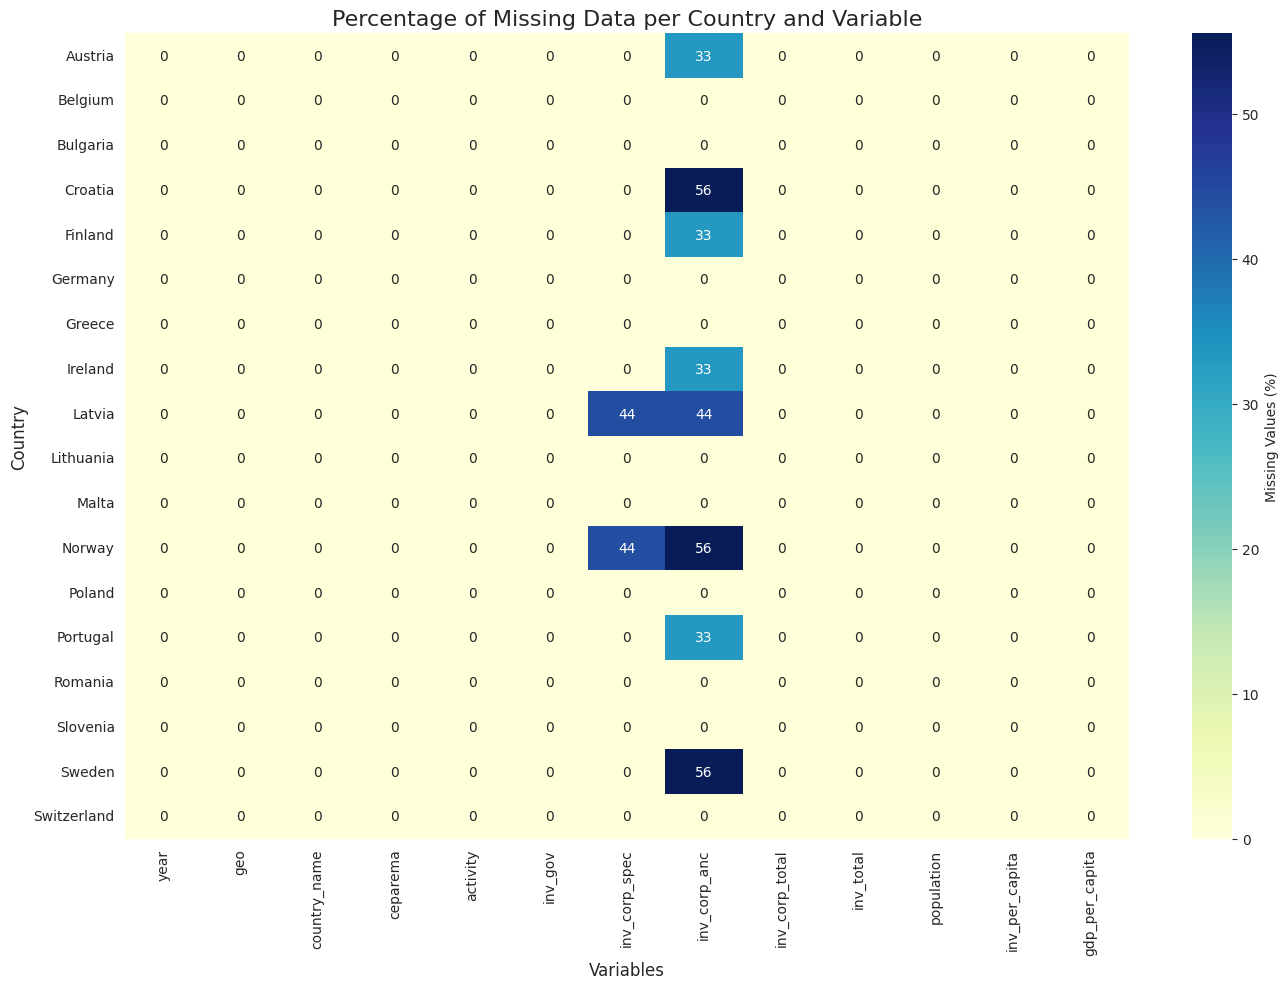

In [105]:
# 1. Calculate the percentage of missing values per country and per variable
# We group by 'country_name' and calculate the mean of the .isnull() mask
df_missing_land = df_cepa_totals.groupby('country_name').apply(lambda x: x.isnull().mean() * 100)

# 2. Visualization
plt.figure(figsize=(14, 10))
# Using a heatmap to visualize the missing data percentage
sns.heatmap(df_missing_land, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Missing Values (%)'})

plt.title("Percentage of Missing Data per Country and Variable", fontsize=16)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()

In [106]:
def get_full_timeseries_matrix(df, column, cepa_filter):
    # Filter for the specific sector (e.g., 'CEPA1', 'CEPA2' or any other)
    df_filtered = df[df['ceparema'] == cepa_filter].copy()
    
    # Check if the filter actually returned data
    if df_filtered.empty:
        return f"No data found for sector: {cepa_filter}"
    
    # Create status indicator (. for present, X for missing)
    df_filtered['Status'] = df_filtered[column].notna().map({True: '.', False: 'X'})
    
    # Create Pivot Table
    matrix = df_filtered.pivot(index='country_name', columns='year', values='Status')
    
    # Fill actual missing years (rows not present in the data)
    matrix = matrix.fillna('X')
    
    print(f"--- Time Series Availability for: {column} | Sector: {cepa_filter} ---")
    return matrix

full_matrix = get_full_timeseries_matrix(df_cepa_totals, column='inv_corp_anc', cepa_filter='TOT_CEPA')
full_matrix

--- Time Series Availability for: inv_corp_anc | Sector: TOT_CEPA ---


year,2014,2015,2016,2017,2018,2019,2020,2021,2022
country_name,,,,,,,,,
Austria,.,.,.,.,.,.,X,X,X
Belgium,.,.,.,.,.,.,.,.,.
Bulgaria,.,.,.,.,.,.,.,.,.
Croatia,.,.,.,.,X,X,X,X,X
Finland,X,X,X,.,.,.,.,.,.
Germany,.,.,.,.,.,.,.,.,.
Greece,.,.,.,.,.,.,.,.,.
Ireland,.,.,.,.,.,.,X,X,X
Latvia,X,X,X,X,.,.,.,.,.


Interpolation is not suitable for the data

Evaluation after Handling Missing Values

In [107]:
# --- 1. Tabular Missing Data Analysis ---
missing_values = df_cepa_totals.isnull().sum()
missing_percent = (df_cepa_totals.isnull().sum() / len(df_cepa_totals) * 100).round(2)

# Create a summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

print("=== Missing Data Summary (df_cepa_totals) ===")
print(missing_df)

=== Missing Data Summary (df_cepa_totals) ===
                Missing Values  Percentage (%)
inv_corp_anc                31           19.14
inv_corp_spec                8            4.94
year                         0            0.00
geo                          0            0.00
country_name                 0            0.00
ceparema                     0            0.00
activity                     0            0.00
inv_gov                      0            0.00
inv_corp_total               0            0.00
inv_total                    0            0.00
population                   0            0.00
inv_per_capita               0            0.00
gdp_per_capita               0            0.00


Duplicate Check

In [108]:
# --- Data Quality: Duplicate Check for National Totals ---

# Define columns that must form a unique identifier for national totals
id_columns_totals = ['year', 'geo']

# Identify all rows that violate uniqueness
duplicates_totals = df_cepa_totals[df_cepa_totals.duplicated(subset=id_columns_totals, keep=False)]

# Validation output
if not duplicates_totals.empty:
    print(f"Warning: {len(duplicates_totals)} duplicate records detected in totals view.")
    # Show the first 10 duplicates for debugging
    print(duplicates_totals.sort_values(by=id_columns_totals).head(10))
else:
    print(f"Validation successful: No duplicates found for {id_columns_totals}.")

# Verification of record counts
unique_entries_totals = df_cepa_totals.groupby(id_columns_totals).ngroups
print(f"Summary: {unique_entries_totals} unique country-year records out of {len(df_cepa_totals)} total rows.")

Validation successful: No duplicates found for ['year', 'geo'].
Summary: 162 unique country-year records out of 162 total rows.


### Missing Data Analysis (df_cepa_breakdown)

In [111]:
df_cepa_breakdown.head()

,year,geo,country_name,ceparema,activity,inv_gov,inv_corp_spec,inv_corp_anc,inv_corp_total,inv_total
0,2014,AT,Austria,CEPA1,Protection of ambient air and climate,6200000,5800000,103500000,109300000,115500000
1,2014,BE,Belgium,CEPA1,Protection of ambient air and climate,3500000,10200000,161100000,171300000,174800000
2,2014,BG,Bulgaria,CEPA1,Protection of ambient air and climate,1700000,0,174900000,174900000,176600000
3,2014,CH,Switzerland,CEPA1,Protection of ambient air and climate,1600000,5800000,114200000,120000000,121600000
4,2014,CY,Cyprus,CEPA1,Protection of ambient air and climate,<NA>,<NA>,<NA>,0,0


In [112]:
# --- 1. Tabular Missing Data Analysis ---
missing_values = df_cepa_breakdown.isnull().sum()
missing_percent = (df_cepa_breakdown.isnull().sum() / len(df_cepa_breakdown) * 100).round(2)

# Create a summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

print("=== Missing Data Summary (df_cepa_breakdown) ===")
print(missing_df)

=== Missing Data Summary (df_cepa_breakdown) ===
                Missing Values  Percentage (%)
inv_corp_anc              1384           53.40
inv_corp_spec              463           17.86
inv_gov                    241            9.30
year                         0            0.00
geo                          0            0.00
country_name                 0            0.00
ceparema                     0            0.00
activity                     0            0.00
inv_corp_total               0            0.00
inv_total                    0            0.00


In [113]:
# Identify countries where inv_corp_anc has more than 80% missing values
missing_stats = df_cepa_breakdown.groupby('country_name')['inv_corp_anc'].apply(lambda x: x.isnull().mean() * 100)
countries_to_drop = missing_stats[missing_stats > 80].index.tolist()

print(f"The following countries will be removed (>80% NaN in inv_corp_anc):")
print(countries_to_drop)

# Filter the df_final to remove identified countries
df_final_cleaned = df_cepa_breakdown[~df_cepa_breakdown['country_name'].isin(countries_to_drop)].copy()

# Quick verification of the filtering results
print(f"\nCountries before filtering: {df_cepa_breakdown['country_name'].nunique()}")
print(f"Countries after filtering: {df_final_cleaned['country_name'].nunique()}")

The following countries will be removed (>80% NaN in inv_corp_anc):
['Cyprus', 'Czechia', 'Denmark', 'Estonia', 'France', 'Hungary', 'Iceland', 'Italy', 'Luxembourg', 'Netherlands', 'Slovakia', 'Spain']

Countries before filtering: 30
Countries after filtering: 18


In [114]:
 # Update df_final with the cleaned version
df_cepa_breakdown = df_final_cleaned

In [115]:
# --- 1. Tabular Missing Data Analysis ---
missing_values = df_cepa_breakdown.isnull().sum()
missing_percent = (df_cepa_breakdown.isnull().sum() / len(df_cepa_breakdown) * 100).round(2)

# Create a summary table
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

print("=== Missing Data Summary (df_cepa_breakdown) ===")
print(missing_df)

=== Missing Data Summary (df_cepa_breakdown) ===
                Missing Values  Percentage (%)
inv_corp_anc               451           27.38
inv_corp_spec              234           14.21
inv_gov                    137            8.32
year                         0            0.00
geo                          0            0.00
country_name                 0            0.00
ceparema                     0            0.00
activity                     0            0.00
inv_corp_total               0            0.00
inv_total                    0            0.00


Duplicate Check

In [116]:
# --- Data Quality: Duplicate Check for Sector Breakdown ---

# Define columns that must form a unique identifier
id_columns = ['year', 'geo', 'ceparema']

# Identify all rows that violate uniqueness
duplicates = df_cepa_breakdown[df_cepa_breakdown.duplicated(subset=id_columns, keep=False)]

# Validation output
if not duplicates.empty:
    print(f"Warning: {len(duplicates)} duplicate records detected.")
    # Show the first 10 duplicates for debugging
    print(duplicates.sort_values(by=id_columns).head(10))
else:
    print(f"Validation successful: No duplicates found for {id_columns}.")

# Verification of record counts
unique_entries = df_cepa_breakdown.groupby(id_columns).ngroups
print(f"Summary: {unique_entries} unique sector-records out of {len(df_cepa_breakdown)} total rows.")

Validation successful: No duplicates found for ['year', 'geo', 'ceparema'].
Summary: 1647 unique sector-records out of 1647 total rows.


### Export the saved data

In [117]:
# Define the output directory
output_dir = os.path.join(DATA_PATH, "processed")
os.makedirs(output_dir, exist_ok=True)

# Define specific filenames for both views
# File A: Sector-specific details
breakdown_file = os.path.join(output_dir, f"{current_date}_investments_sector_breakdown.csv")

# File B: National totals for Regression/Clustering
totals_file = os.path.join(output_dir, f"{current_date}_investments_national_totals.csv")

# 4. Save the DataFrames
df_cepa_breakdown.to_csv(breakdown_file, index=False)
df_cepa_totals.to_csv(totals_file, index=False)

print(f"Breakdown data saved as: {os.path.basename(breakdown_file)}")
print(f"National totals saved as: {os.path.basename(totals_file)}")

Breakdown data saved as: 20260505_investments_sector_breakdown.csv
National totals saved as: 20260505_investments_national_totals.csv


### Analysis of Datasets

View A: Protection Activities separately

=== 1. General information ===
Shape: (1647, 10)

Datatypes:
year               int64
geo               object
country_name      object
ceparema          object
activity          object
inv_gov            Int64
inv_corp_spec      Int64
inv_corp_anc       Int64
inv_corp_total     Int64
inv_total          Int64
dtype: object


,year,inv_gov,inv_corp_spec,inv_corp_anc,inv_corp_total,inv_total
count,1647.000000,1510.0,1413.0,1196.0,1647.0,1647.0
mean,2018.000000,63144039.735099,74826610.04954,52275000.0,102155980.570735,160047601.700061
std,2.582773,175314374.713025,432137367.074732,160033383.971457,493899063.186395,620284842.863964
min,2014.000000,0.0,0.0,0.0,0.0,0.0
25%,2016.000000,100000.0,0.0,0.0,0.0,1000000.0
50%,2018.000000,5400000.0,200000.0,4900000.0,4800000.0,18300000.0
75%,2020.000000,37325000.0,17800000.0,37800000.0,51200000.0,94300000.0
max,2022.000000,1968000000.0,5657000000.0,1810100000.0,6695600000.0,8608600000.0



=== 2. Distribution ===


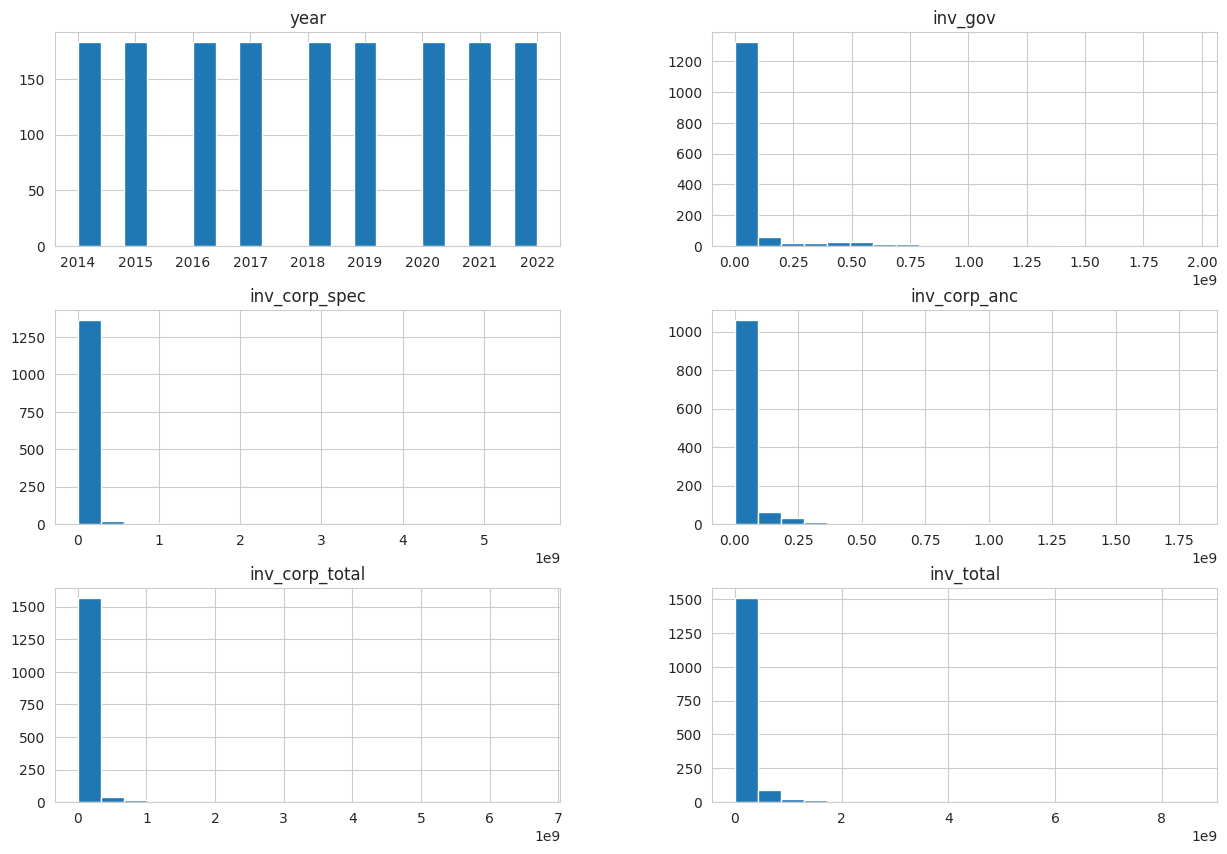


=== 3. Correlation of numeric columns ===


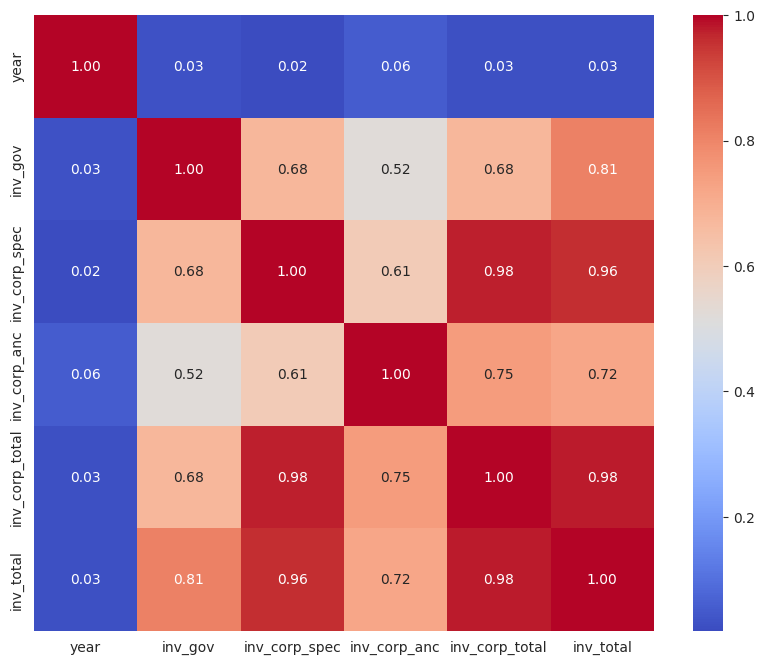

In [118]:
print("=== 1. General information ===")
print("Shape:", df_cepa_breakdown.shape)
print("\nDatatypes:")
print(df_cepa_breakdown.dtypes)
display(df_cepa_breakdown.describe())

print("\n=== 2. Distribution ===")
num_cols = df_cepa_breakdown.select_dtypes(include='number').columns.tolist()
if num_cols:
    # Show histograms
    df_cepa_breakdown[num_cols].hist(bins=20, figsize=(15,10))
    plt.show()

print("\n=== 3. Correlation of numeric columns ===")
if len(num_cols) > 1:
    corr = df_cepa_breakdown[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
    plt.show()

View B: Investment Totals

=== 1. General information ===
Shape: (162, 13)

Datatypes:
year                int64
geo                object
country_name       object
ceparema           object
activity           object
inv_gov             Int64
inv_corp_spec       Int64
inv_corp_anc        Int64
inv_corp_total      Int64
inv_total           Int64
population        float64
inv_per_capita    float64
gdp_per_capita    float64
dtype: object


,year,inv_gov,inv_corp_spec,inv_corp_anc,inv_corp_total,inv_total,population,inv_per_capita,gdp_per_capita
count,162.000000,162.0,154.0,131.0,162.0,162.0,1.620000e+02,162.000000,162.000000
mean,2018.000000,573590740.740741,667979870.12987,471726717.557252,1016451234.567901,1590041975.308642,1.296331e+07,114.736794,33033.765432
std,2.589995,780757055.588755,1604733741.495893,738829723.57271,2226574854.125347,2929072666.719415,1.883161e+07,71.664502,21230.306417
min,2014.000000,8700000.0,1400000.0,1100000.0,0.0,13800000.0,4.281560e+05,9.649779,7770.000000
25%,2016.000000,78250000.0,42725000.0,56750000.0,113100000.0,287625000.0,4.030448e+06,57.097559,15372.500000
50%,2018.000000,302100000.0,134250000.0,196600000.0,258350000.0,635450000.0,7.628542e+06,96.566462,24350.000000
75%,2020.000000,844950000.0,457700000.0,540750000.0,985700000.0,1602050000.0,1.065931e+07,161.041798,44252.500000
max,2022.000000,3692000000.0,8209500000.0,3822200000.0,12031700000.0,15059200000.0,8.323712e+07,290.017235,91760.000000



=== 2. Distribution ===


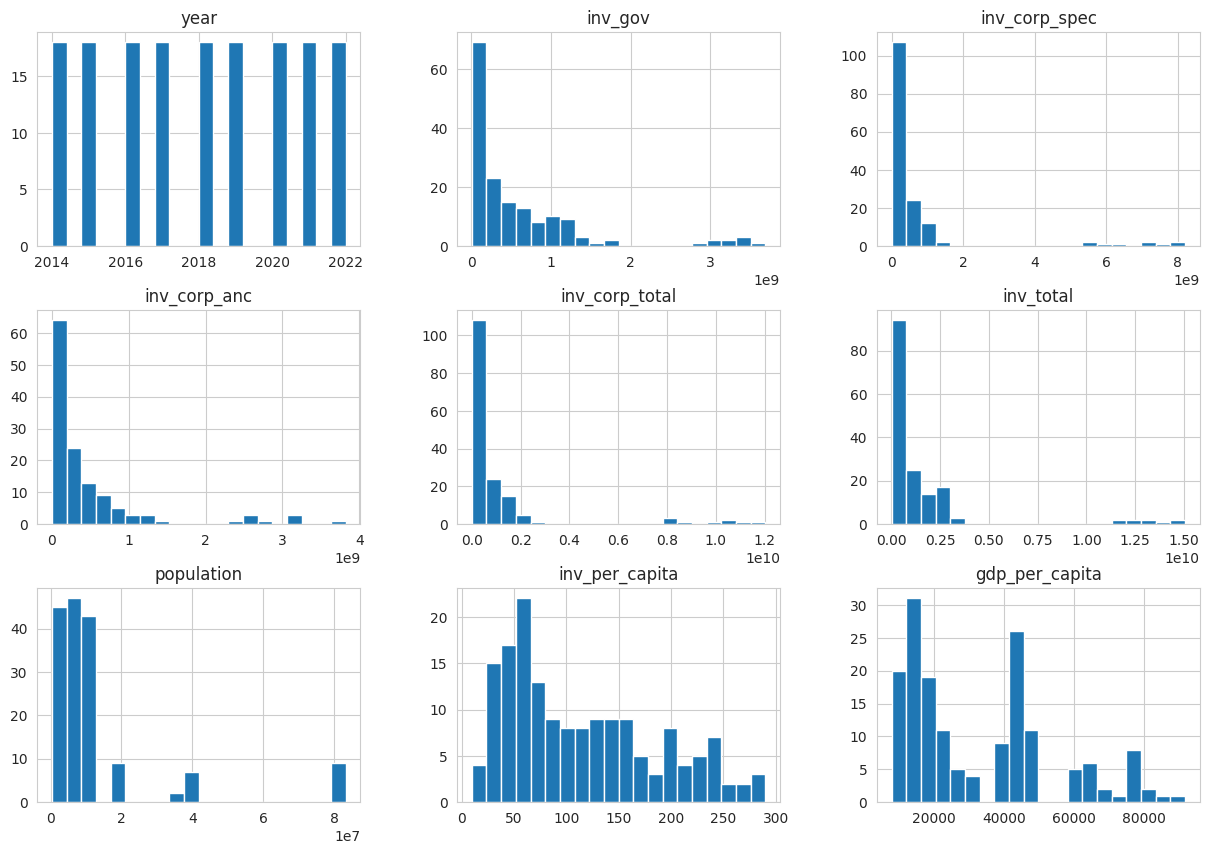


=== 3. Correlation of numeric columns===


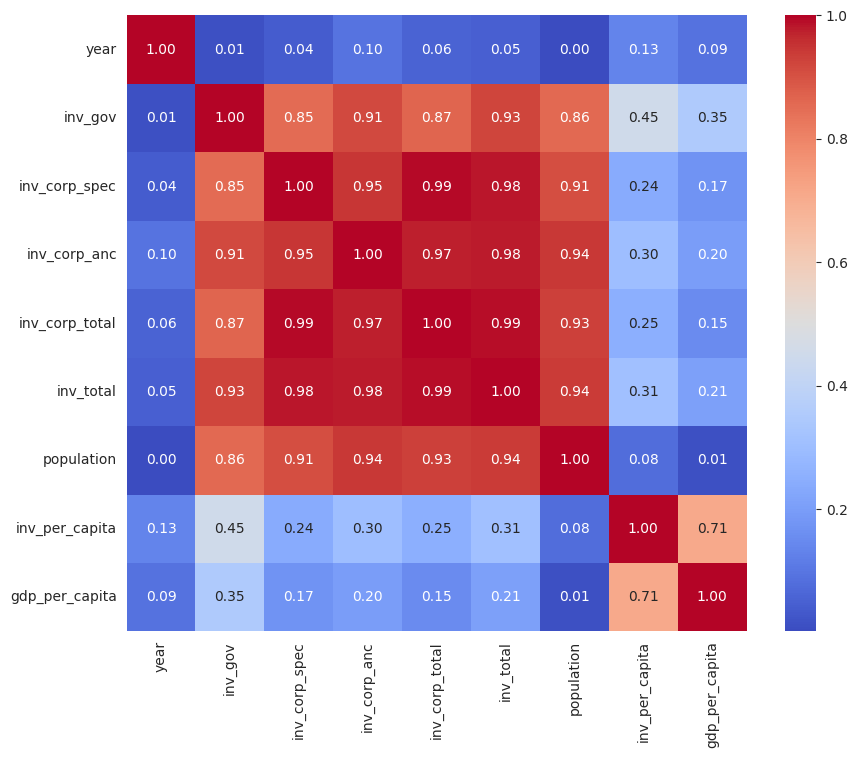

In [119]:
print("=== 1. General information ===")
print("Shape:", df_cepa_totals.shape)
print("\nDatatypes:")
print(df_cepa_totals.dtypes)
display(df_cepa_totals.describe())

print("\n=== 2. Distribution ===")
num_cols = df_cepa_totals.select_dtypes(include='number').columns.tolist()
if num_cols:
    # Show histograms
    df_cepa_totals[num_cols].hist(bins=20, figsize=(15,10))
    plt.show()

print("\n=== 3. Correlation of numeric columns===")
if len(num_cols) > 1:
    corr = df_cepa_totals[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
    plt.show()

## Data Exploration

### Trend Analysis (Investments by Protection Activity & Country)

Successfully saved plot to: ../figures/20260505_investment_trends_by_country.png


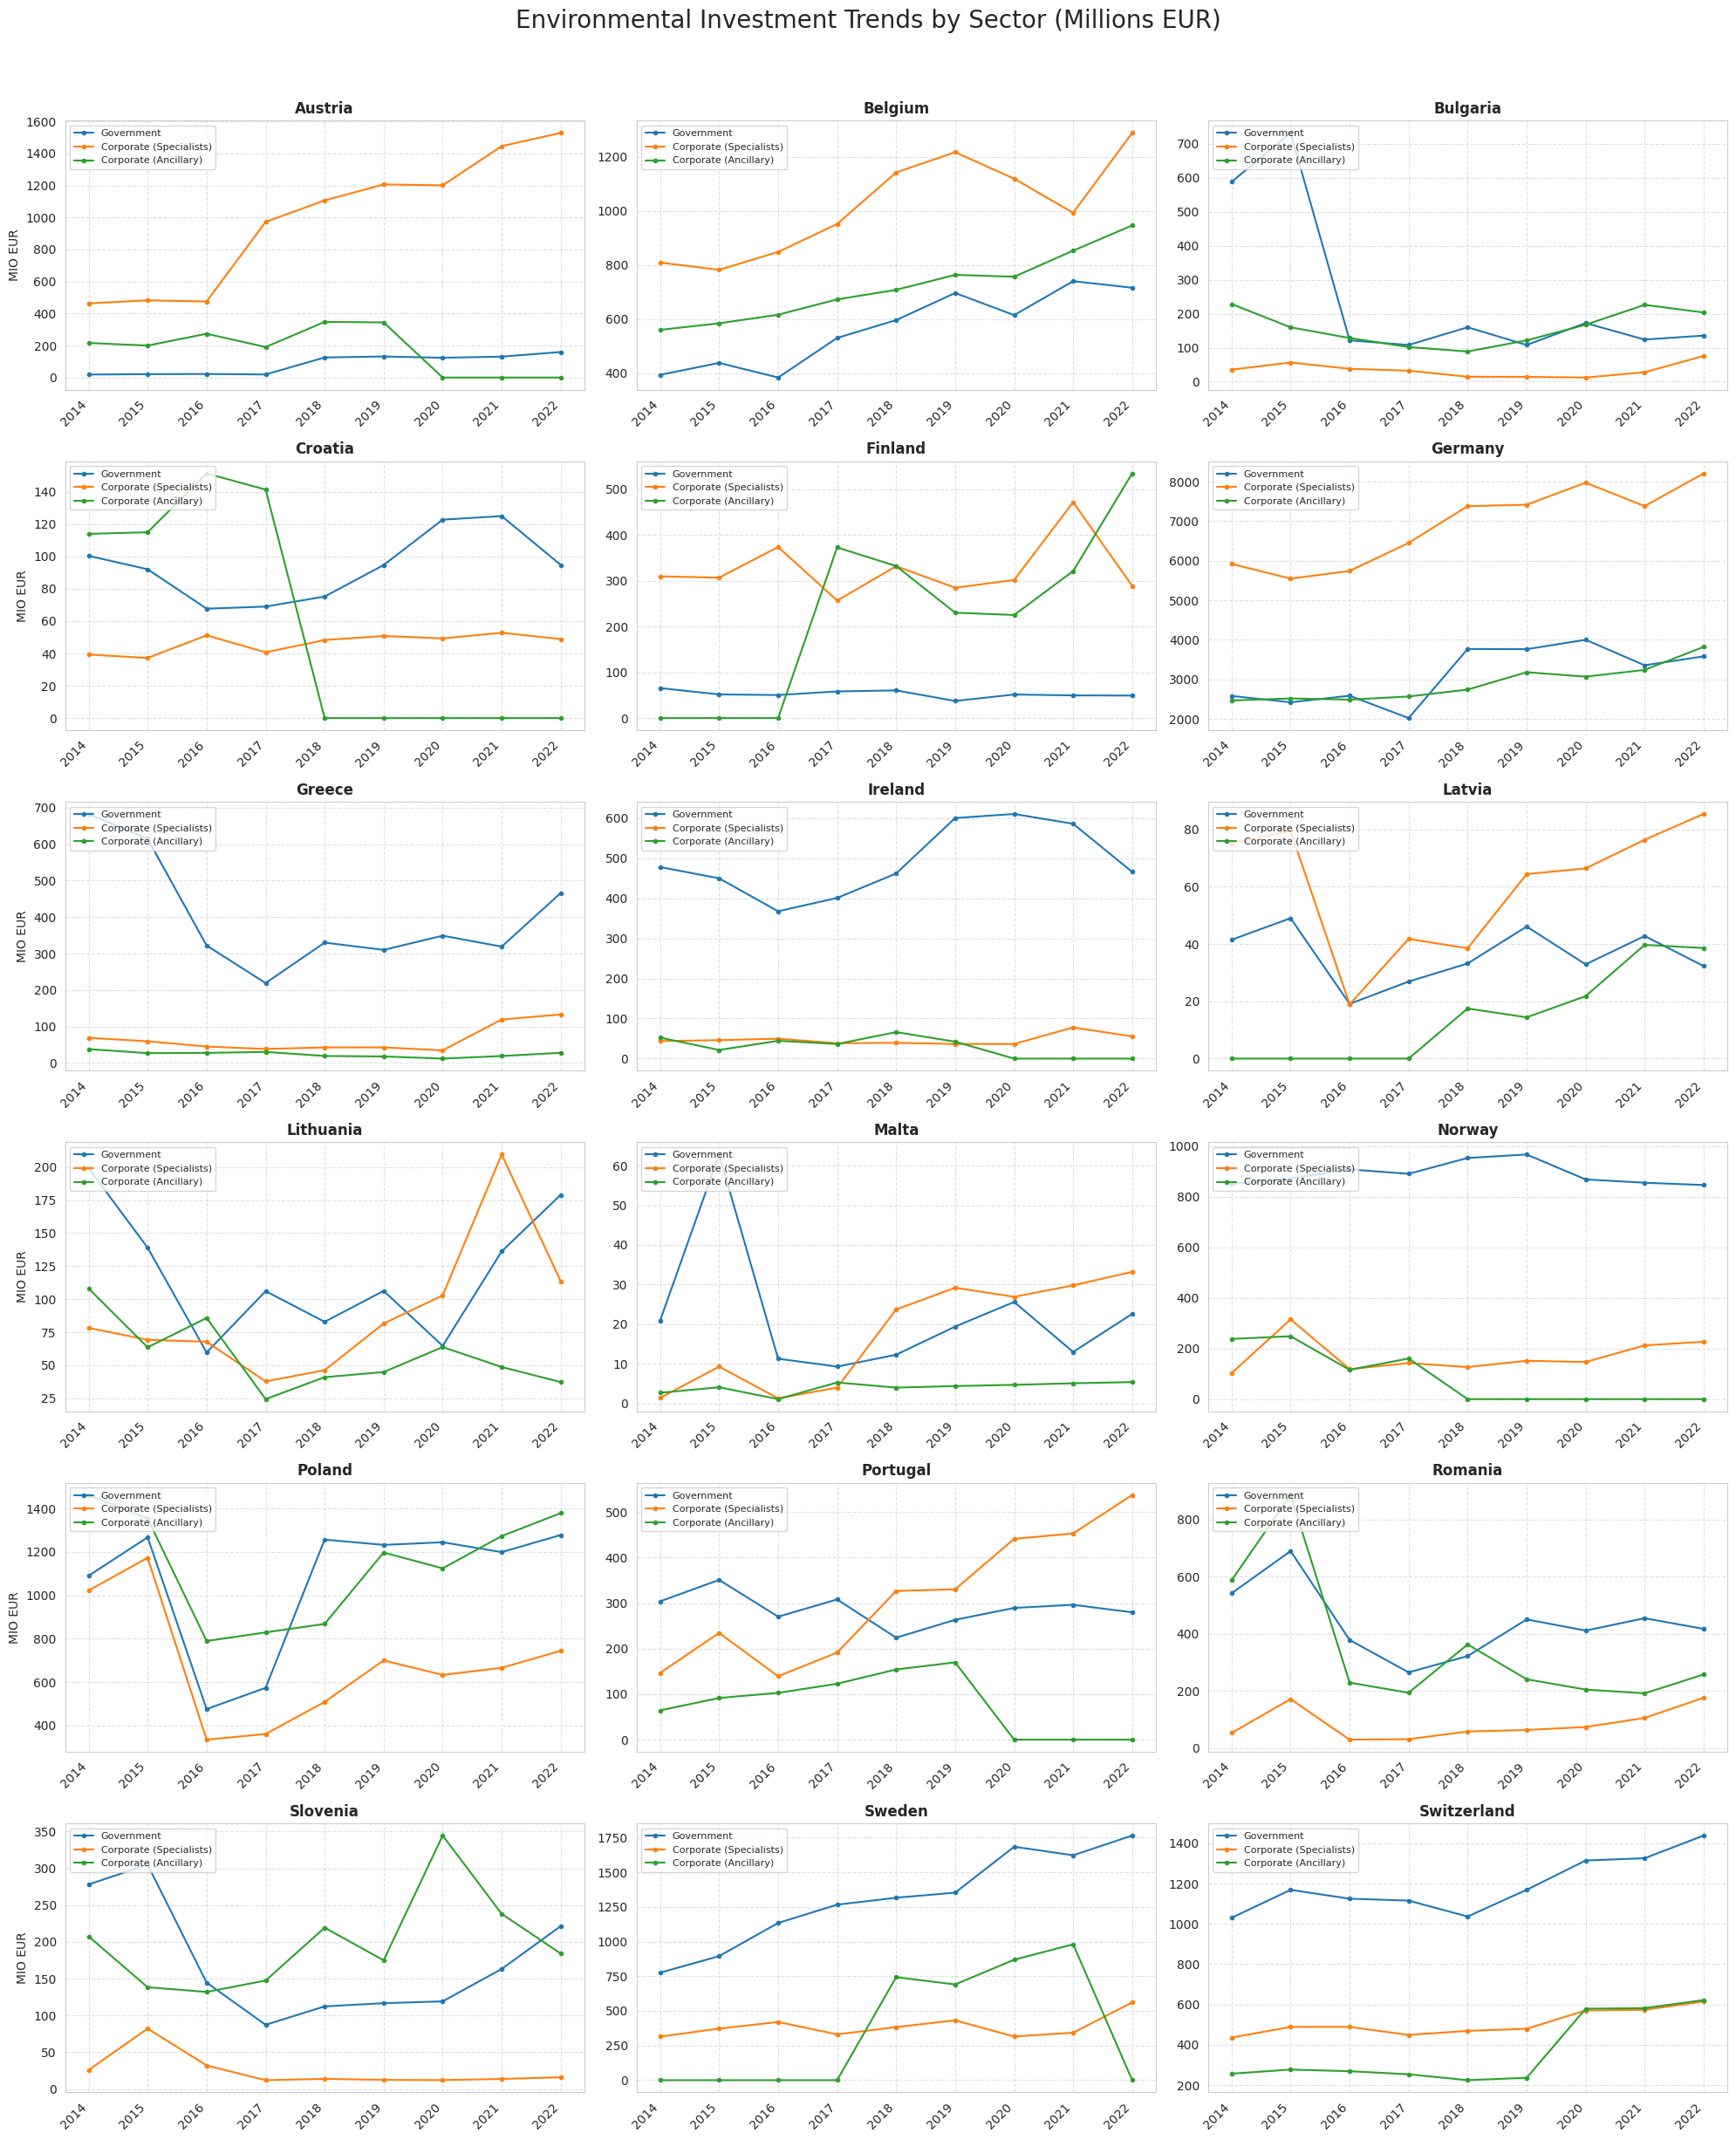

In [120]:
# Get sorted list of unique countries
countries = sorted(df_cepa_breakdown['country_name'].dropna().unique())
n_countries = len(countries)

# Calculate Layout
cols = 3
rows = (n_countries // cols) + (1 if n_countries % cols > 0 else 0)

# Create the figure
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

# Define labels and colors
# Using a clear color scheme: Blue for Government, Orange for Corporate (Specialists), Green for Corporate (Ancillary)
for i, country in enumerate(countries):
    ax = axes[i]
    
    # Filter data for the specific country
    c_data = df_cepa_breakdown[df_cepa_breakdown['country_name'] == country]
    
    # Group by year and sum values, converting to Millions for readability (MIO EUR)
    gov_trend = c_data.groupby('year')['inv_gov'].sum() / 1_000_000
    spec_trend = c_data.groupby('year')['inv_corp_spec'].sum() / 1_000_000
    anc_trend = c_data.groupby('year')['inv_corp_anc'].sum() / 1_000_000
    
    # Plotting each investment stream separately
    ax.plot(gov_trend.index, gov_trend.values, 
            label='Government', color='#1f77b4', marker='.', linewidth=1.5)
    
    ax.plot(spec_trend.index, spec_trend.values, 
            label='Corporate (Specialists)', color='#ff7f0e', marker='.', linewidth=1.5)
    
    ax.plot(anc_trend.index, anc_trend.values, 
            label='Corporate (Ancillary)', color='#2ca02c', marker='.', linewidth=1.5)
    
    # Formatting the subplot
    ax.set_title(country, fontsize=12, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, linestyle='--', alpha=0.6)

    # Rotate the ticks for the year axis to avoid overlapping
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Add legend to the subplot
    ax.legend(fontsize=8, loc='upper left')
    
    # Add Y-label to the first column only to save space and reduce clutter
    if i % cols == 0:
        ax.set_ylabel('MIO EUR')

# Delete empty subplots at the end of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Main title for the entire figure
plt.suptitle('Environmental Investment Trends by Sector (Millions EUR)', fontsize=20, y=1.02)
plt.tight_layout()

# Save the figure
plot_filename = f"{current_date}_investment_trends_by_country.png"
try:
    export_path = os.path.join(FIGURES_PATH, plot_filename)
except NameError:
    export_path = plot_filename

plt.savefig(export_path, bbox_inches='tight', dpi=300)
print(f"Successfully saved plot to: {export_path}")

Be careful: The y-axis has a different range for each country. Each country must be considered separately. 

### Category Analysis (Investments by Protection Activity & Sector)

Category plot saved successfully to: ../figures/20260505_investment_by_protection_activity.png


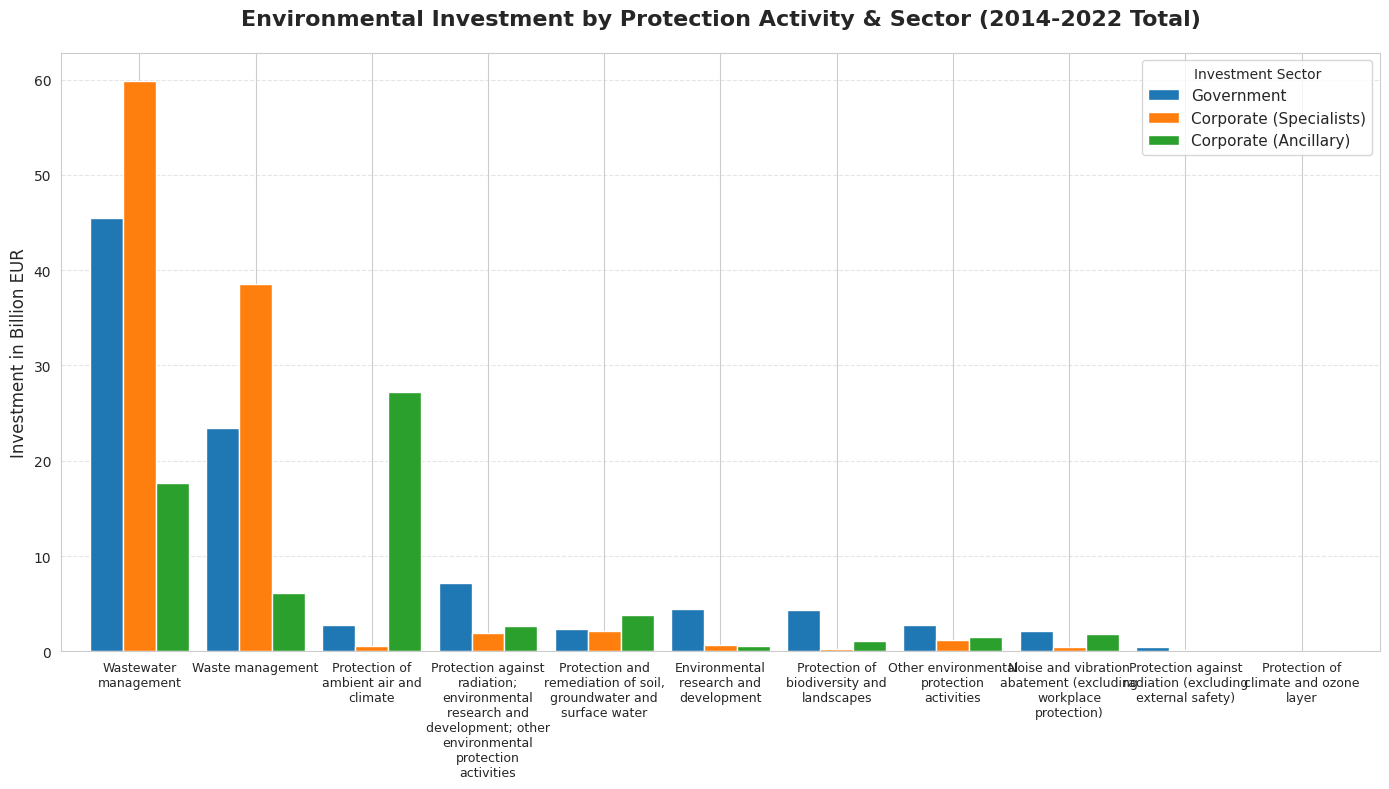

In [121]:
# Group by activity and sum all three investment streams
category_summary = df_cepa_breakdown.groupby('activity')[['inv_gov', 'inv_corp_spec', 'inv_corp_anc']].sum()

# Convert values to Billion EUR (Divide by 10^9)
category_summary = category_summary / 1_000_000_000

# Sort the categories based on the combined total effort (Gov + Spec + Anc)
category_summary['total_sum'] = category_summary.sum(axis=1)
category_summary = category_summary.sort_values(by='total_sum', ascending=False).drop(columns='total_sum')

# Wrap long category names into multiple lines for better readability
wrapped_labels = [textwrap.fill(label, width=20) for label in category_summary.index]
category_summary.index = wrapped_labels

# Create the vertical bar chart
# Using a grouped bar chart to compare the three sectors side-by-side
ax = category_summary.plot(
    kind='bar', 
    figsize=(14, 8), 
    color=['#1f77b4', '#ff7f0e', '#2ca02c'], # Blue, Orange, Green
    width=0.85
)

# Add styling and labels
plt.title('Environmental Investment by Protection Activity & Sector (2014-2022 Total)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Investment in Billion EUR', fontsize=12)
plt.xlabel('', fontsize=12)
plt.xticks(rotation=0, fontsize=9) # Keeps wrapped labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Clear legend with specific descriptions
plt.legend(
    ['Government', 'Corporate (Specialists)', 'Corporate (Ancillary)'], 
    title='Investment Sector', 
    fontsize=11
)

# Optimize layout to prevent text clipping
plt.tight_layout()

# --- Save Figure ---
cat_plot_filename = f"{current_date}_investment_by_protection_activity.png"
try:
    cat_save_path = os.path.join(FIGURES_PATH, cat_plot_filename)
except NameError:
    cat_save_path = cat_plot_filename

plt.savefig(cat_save_path, bbox_inches='tight', dpi=300)
print(f"Category plot saved successfully to: {cat_save_path}")

### Correlation Analysis (Investments Total)

Scatter plot saved successfully to: ../figures/20260505_gdp_investment_correlation.png
The Pearson correlation coefficient is: 0.71


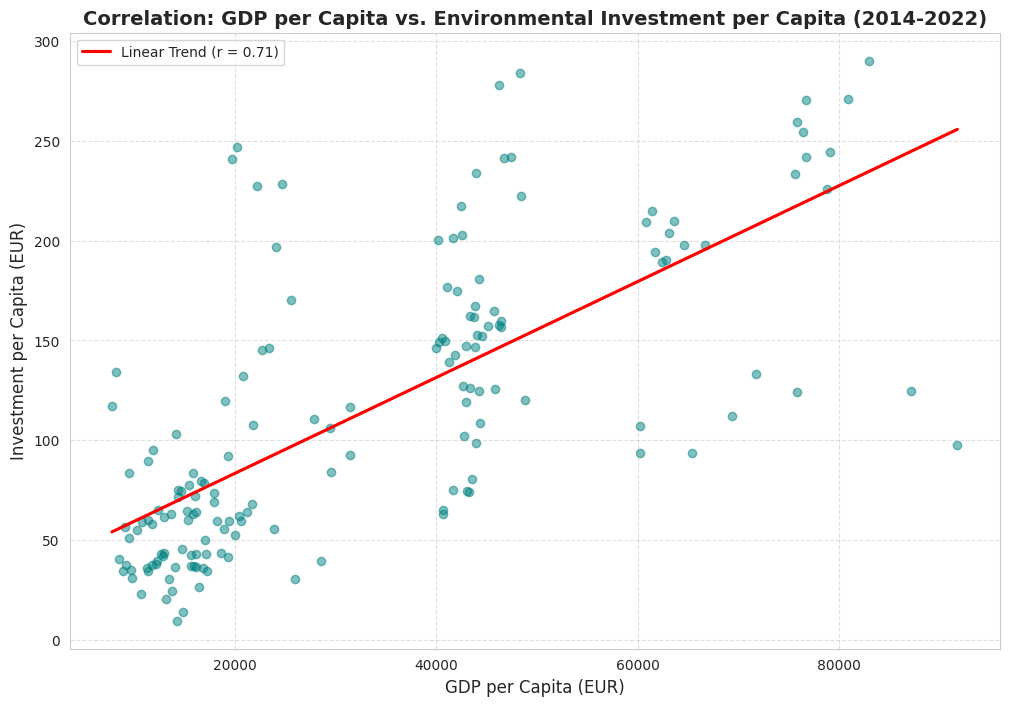

In [122]:
# Use the df_cepa_totals to avoid double counting
df_scatterplot = df_cepa_totals.dropna(subset=['gdp_per_capita', 'inv_per_capita']).copy()

# Create the Scatterplot with a regression line
plt.figure(figsize=(12, 8))

# Using regplot to show the linear relationship between wealth and effort
sns.regplot(
    data=df_scatterplot, 
    x='gdp_per_capita', 
    y='inv_per_capita',
    ci=None,
    scatter_kws={'alpha': 0.5, 'color': 'teal'},
    line_kws={'color': 'red', 'label': f'Linear Trend (r = {df_scatterplot["gdp_per_capita"].corr(df_scatterplot["inv_per_capita"]):.2f})'}
)

# Styling and Labels
plt.title('Correlation: GDP per Capita vs. Environmental Investment per Capita (2014-2022)', fontsize=14, fontweight='bold')
plt.xlabel('GDP per Capita (EUR)', fontsize=12)
plt.ylabel('Investment per Capita (EUR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save Figure
scatter_plot_filename = f"{current_date}_gdp_investment_correlation.png"
try:
    scatter_save_path = os.path.join(FIGURES_PATH, scatter_plot_filename)
except NameError:
    scatter_save_path = scatter_plot_filename

plt.savefig(scatter_save_path, bbox_inches='tight', dpi=300)
print(f"Scatter plot saved successfully to: {scatter_save_path}")

# Statistical Output
correlation = df_scatterplot['gdp_per_capita'].corr(df_scatterplot['inv_per_capita'])
print(f"The Pearson correlation coefficient is: {correlation:.2f}")

## Supervised Learning - Regression (Investment Totals)

In [123]:
# Check whether log transformation improves normality for gdp_per_capita, population and inv_per_capita.
df_diag = df_cepa_totals[['gdp_per_capita', 'population', 'inv_per_capita']].dropna()

variables = {
    'gdp_per_capita': df_diag['gdp_per_capita'],
    'population':     df_diag['population'],
    'inv_per_capita': df_diag['inv_per_capita'],
}

print("=" * 50)
print("NORMALITY (Skewness)")
print("=" * 50)
print(f"{'Variable':<22} {'Skew (raw)':>10} {'Skew (log)':>11} ")
print("-" * 50)

for name, series in variables.items():
    log_series = np.log1p(series)

    # Calculate skewness: goal is to get as close to 0.000 as possible
    # Skewness measures the asymmetry of the probability distribution. 
    # A value of 0 indicates a perfectly symmetrical (normal) distribution. 
    skew_raw = series.skew()
    skew_log = log_series.skew()

    print(f"{name:<22} {skew_raw:>10.3f} {skew_log:>11.3f}")

NORMALITY (Skewness)
Variable               Skew (raw)  Skew (log) 
--------------------------------------------------
gdp_per_capita              0.810       0.037
population                  2.907      -0.083
inv_per_capita              0.649      -0.356


In [124]:
# Research question: Does GDP per capita predict environmental investment per capita?

# --- Preparation ---
df_ml = df_cepa_totals.copy()

# Log-transform skewed variables (GDP and investment are right-skewed)
df_ml['log_gdp_per_capita'] = np.log1p(df_ml['gdp_per_capita'])
df_ml['log_inv_per_capita'] = np.log1p(df_ml['inv_per_capita'])

# Drop rows missing any required variable
df_ml = df_ml.dropna(subset=['log_gdp_per_capita', 'log_inv_per_capita'])

# --- Time-Based Train/Test Split ---
# Train on 2014-2019, test on 2020-2022
# This tests whether the historical wealth-investment relationship holds in recent years
train_df = df_ml[df_ml['year'] <= 2019]
test_df  = df_ml[df_ml['year'] >= 2020]

print(f"Training samples : {len(train_df)} ({train_df['year'].min()}–{train_df['year'].max()})")
print(f"Test samples     : {len(test_df)}  ({test_df['year'].min()}–{test_df['year'].max()})")
print(f"Countries in test: {test_df['geo'].nunique()}")

Training samples : 108 (2014–2019)
Test samples     : 54  (2020–2022)
Countries in test: 18


In [126]:
# --- Feature Definition ---
# Features: log GDP per capita, log population
features = ['log_gdp_per_capita', 'log_pop']

# Add log population if available
df_ml['log_pop'] = np.log1p(df_ml['population'])
train_df = df_ml[df_ml['year'] <= 2019]
test_df  = df_ml[df_ml['year'] >= 2020]

target = 'log_inv_per_capita'  # predict log investment per capita

X_train = train_df[features]
X_test  = test_df[features]
y_train = train_df[target]
y_test  = test_df[target]

In [127]:
# --- Model Training ---
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# --- Evaluation ---
def evaluate(name, model, X, y):
    preds = model.predict(X)
    return {
        "Model": name,
        "MAE":  mean_absolute_error(y, preds),
        "RMSE": np.sqrt(mean_squared_error(y, preds)),
        "R2":   r2_score(y, preds)
    }

results = [
    evaluate("Linear Regression", lr_model, X_test, y_test),
    evaluate("Random Forest",     rf_model, X_test, y_test),
]

perf_df = pd.DataFrame(results)
print("\n" + "="*45)
print("PERFORMANCE COMPARISON (log scale)")
print("="*45)
print(perf_df.to_string(index=False))


PERFORMANCE COMPARISON (log scale)
            Model      MAE     RMSE       R2
Linear Regression 0.335210 0.417737 0.556647
    Random Forest 0.272485 0.333632 0.717201


In [128]:
# --- Linear Regression Coefficient ---
# In log-log space, the coefficient on log_gdp is an elasticity:
# "A 1% increase in GDP per capita is associated with a X% increase in investment per capita"
gdp_coef = lr_model.coef_[0]
print(f"\nLinear Regression: GDP elasticity of investment = {gdp_coef:.3f}")
print(f"Interpretation: 1% higher GDP per capita → {gdp_coef:.2f}% higher inv per capita (on average)")


Linear Regression: GDP elasticity of investment = 0.742
Interpretation: 1% higher GDP per capita → 0.74% higher inv per capita (on average)


In [129]:
# --- Export Results ---
results_filename = os.path.join(RESULTS_PATH, f"{current_date}_reg_model_performance_comparison.csv")
perf_df.to_csv(results_filename, index=False)
print(f"\nResults saved to: {os.path.basename(results_filename)}")


Results saved to: 20260505_reg_model_performance_comparison.csv


Figure saved to: 20260505_regression_actual_vs_predicted.png


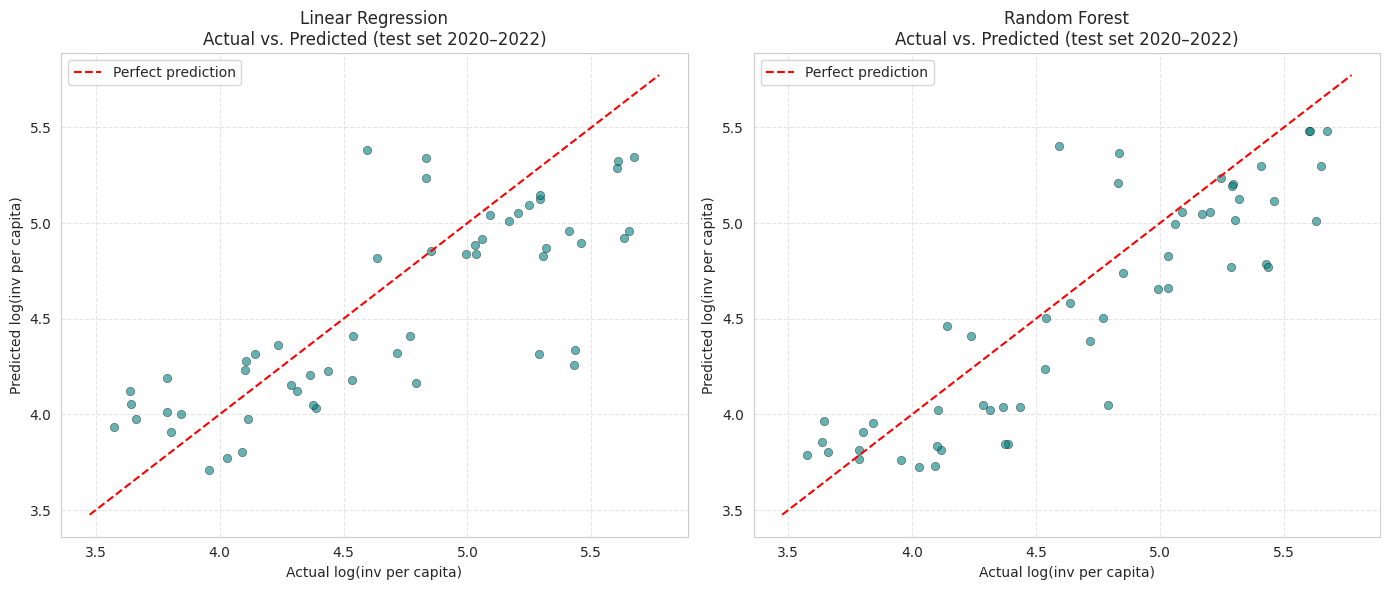

In [130]:
# --- Visualization: Actual vs Predicted (log scale) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, model) in zip(axes, [("Linear Regression", lr_model), ("Random Forest", rf_model)]):
    preds = model.predict(X_test)
    ax.scatter(y_test, preds, alpha=0.6, color='teal', edgecolors='k', linewidth=0.4)
    lims = [min(y_test.min(), preds.min()) - 0.1, max(y_test.max(), preds.max()) + 0.1]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual log(inv per capita)')
    ax.set_ylabel('Predicted log(inv per capita)')
    ax.set_title(f'{name}\nActual vs. Predicted (test set 2020–2022)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig_filename = os.path.join(FIGURES_PATH, f"{current_date}_regression_actual_vs_predicted.png")
plt.savefig(fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {os.path.basename(fig_filename)}")
plt.show()

In [132]:
# --- Define filenames  ---
lr_filename = os.path.join(MODELS_PATH, f"{current_date}_linear_regression.joblib")
rf_filename = os.path.join(MODELS_PATH, f"{current_date}_random_forest.joblib")

# --- Exporting Models for Reproducibility ---
try:
    # Ensure the models and results directories exist
    os.makedirs(MODELS_PATH, exist_ok=True)
    os.makedirs(RESULTS_PATH, exist_ok=True)
    
    # Save Model Artefacts
    joblib.dump(rf_model, rf_filename)
    joblib.dump(lr_model, lr_filename)
    
    print("EXPORT SUCCESSFUL")
    print(f"Model saved:   {os.path.basename(rf_filename)}")
    print(f"Model saved:   {os.path.basename(lr_filename)}")

except Exception as e:
    print(f"An error occurred while saving the project artefacts: {e}")

EXPORT SUCCESSFUL
Model saved:   20260505_random_forest.joblib
Model saved:   20260505_linear_regression.joblib
